<a href="https://colab.research.google.com/github/montherjafar-cell/TimeSeries-AnomalyDetection/blob/main/TimeSeriesAnomalyDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Memory usage time series anomaly detection**
#For each section, refer to the repository README for more information.






In [1]:
# Uncomment to install required packages on Google Colab
# !pip install pandas
# !pip install numpy
# !pip install matplotlib
# !pip install scikit-learn
# !pip install gdown

In [2]:
import numpy as np
import pandas as pd
from pandas import DataFrame as df
from sklearn.neighbors import LocalOutlierFactor
import matplotlib.pyplot as plt

##Data pipeline & Loading
Time series metrics recorded through prmon were distributed across multiple text files stored in Google drive, containing baseline ordinary runs and anomalous runs.

The function below loads the files into memory, reads them into a pandas dataframe, and isolates the columns 'wtime' and 'pss'. runs are loaded in and concatenated together with anomalous runs injected between them to create the model dataset. Resulting time series is plotted.

In [3]:
def load_file(file_id):


  file_url = f"https://drive.google.com/uc?id={file_id}"

  #remove all columns except for wtime and pss
  columns_to_remove = ['Time', 'rss', 'swap', 'vmem', 'rchar', 'read_bytes', 'wchar',
       'write_bytes', 'rx_bytes', 'rx_packets', 'tx_bytes', 'tx_packets',
       'stime', 'utime', 'nprocs', 'nthreads']

  df = pd.read_csv(file_url, sep = '\t')

  df = df.drop(labels = columns_to_remove, axis = 1)

  return df



drive_files = {
  'Run 1': '1XLL86VCustIekSB8bTMmr0FaTJMfebdi',
  'Anomaly 1': '1jIezdAwAXx5t6hVUw1c3sXmJHP9Y4ChC',
  'Run 2': '180V9p3i7aKU4-eonMnA6ZWVl1Aroo6Hk',
  'Run 3': '1RtH0KVLTSiNwHpWvNUIyMIwIwsCAP2E0',
  'Run 4': '1YbgnY_fWzurZcckG6IC5-zw58KtU205a',
  'Anomaly 2': '1wmoAkubNtSp2fuTVsGWvffjNNXKiMx3X',
  'Run 5': '1HdMjwIsh0G2MKIaphoxIXkOPPC0oe1wq',
  'Run 6': '1gFUGGDd16o5C3ypfmUB2gMklHYcKYtDz',
  'Anomaly 3': '126BZY2fbHfkisCVZEUJ4GDRO6hAsXwZv',
  'Run 7': '1Z3J-vczJGXaXujvkO9H4zI44xQ9Hb1uI',
}

datasets = []

#Load all files in dictionary and add to list
for name, ID in drive_files.items():
  data_series = load_file(ID)
  datasets.append(data_series)
  # print(f"Loaded {name} shape: {data_series.shape}")

#Concatenate files together into time series and plot
time_series = pd.concat(datasets, ignore_index= True)
print(f'Final time series shape: {time_series.shape}')


Final time series shape: (1193, 2)


##Anomaly detection
the Local outlier factor algorithm is used to detect the anomalies in the data, with the number of kneighbor queries set to 550.

In [4]:
#Isolate pss column to fit on.
X_train = time_series[['pss']]

#Initialize model and parameter and make predictions.
model = LocalOutlierFactor(n_neighbors=550)
predictions = model.fit_predict(X_train)
time_series['predictions'] = predictions.tolist()

##Results and Visualizations
The model's predictions are mapped against the time series, with flagged points marked in red.

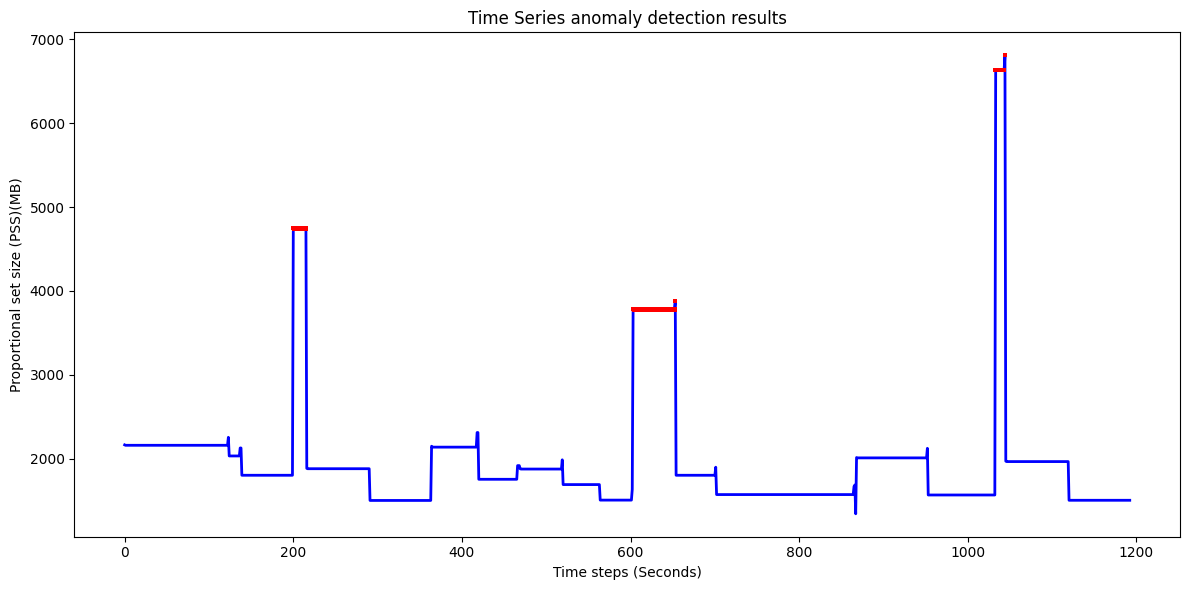

In [5]:
# @title
plt.figure(figsize = (12, 6))

# Plot the original timeseries
plt.plot(time_series.index, time_series['pss'], label= 'Memory Usage (PSS)', color= 'blue', linewidth=2)


# Isolate flagged timestamps
anomalies = time_series[time_series['predictions'] == -1]

# Plot model's predictions over the timeseries
plt.scatter(anomalies.index, anomalies['pss'], color= 'red', zorder=5, s=10, edgecolors='none', marker='s' )

plt.title("Time Series anomaly detection results")
plt.xlabel("Time steps (Seconds)")
plt.ylabel('Proportional set size (PSS)(MB)')
plt.tight_layout()
plt.show()